In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import seaborn as sns
from PIL import Image

In [2]:
np.random.seed(42)
from sklearn.metrics import confusion_matrix


In [3]:
import keras
from keras.utils import to_categorical
 # used for converting labels to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [4]:
skin_df = pd.read_csv('data/HAM10000/HAM10000_metadata.csv')

In [5]:
skin_df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


### Add numeric endocing values to text labels

In [6]:
le = LabelEncoder()
le.fit(skin_df['dx'])
LabelEncoder()
print(list(le.classes_))

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [7]:
skin_df['label'] = le.transform(skin_df["dx"]) 
print(skin_df.sample(10))

        lesion_id      image_id   dx    dx_type   age     sex  \
1617  HAM_0007180  ISIC_0033272  mel      histo  65.0    male   
8128  HAM_0007195  ISIC_0031923   nv      histo  40.0  female   
2168  HAM_0001835  ISIC_0026652  mel      histo  65.0    male   
1090  HAM_0000465  ISIC_0030583  bkl  consensus  35.0  female   
7754  HAM_0001720  ISIC_0034010   nv      histo  45.0    male   
8071  HAM_0006333  ISIC_0024424   nv      histo  35.0    male   
7423  HAM_0004548  ISIC_0032832   nv      histo  45.0  female   
8984  HAM_0006526  ISIC_0026671   nv      histo  55.0    male   
2310  HAM_0003102  ISIC_0032389  mel      histo  65.0    male   
7256  HAM_0004260  ISIC_0025525   nv      histo  65.0    male   

         localization  label  
1617             face      4  
8128  lower extremity      5  
2168             back      4  
1090            trunk      2  
7754          abdomen      5  
8071            trunk      5  
7423  upper extremity      5  
8984  lower extremity      5  
2310 

In [41]:
fig = plt.figure(figsize=(12,8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [45]:
ax1 = fig.add_subplot(221)
skin_df['dx'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count')
ax1.set_title('Cell Type');
print(ax1)
plt.show(ax1)

Axes(0.125,0.53;0.352273x0.35)


In [10]:
ax2 = fig.add_subplot(222)
skin_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count', size=15)
ax2.set_title('Sex');
print(ax2)

Axes(0.547727,0.53;0.352273x0.35)


Text(0.5, 1.0, 'Localization')

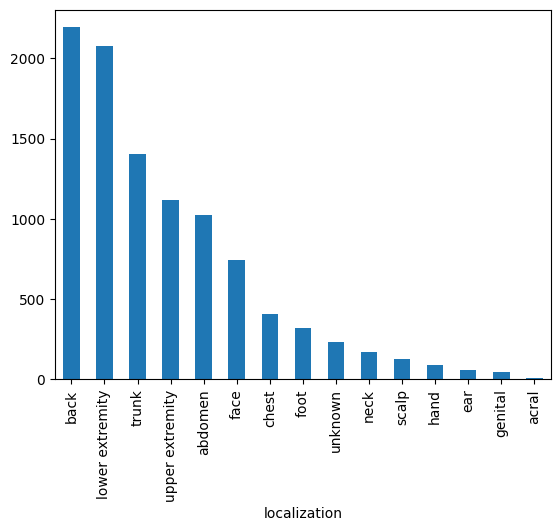

In [11]:
ax3 = fig.add_subplot(223)
skin_df['localization'].value_counts().plot(kind='bar')
ax3.set_ylabel('Count',size=12)
ax3.set_title('Localization')

C:\Users\Acer\AppData\Local\Temp\ipykernel_13732\1874541861.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample_age['age'], fit=stats.norm, color='red');


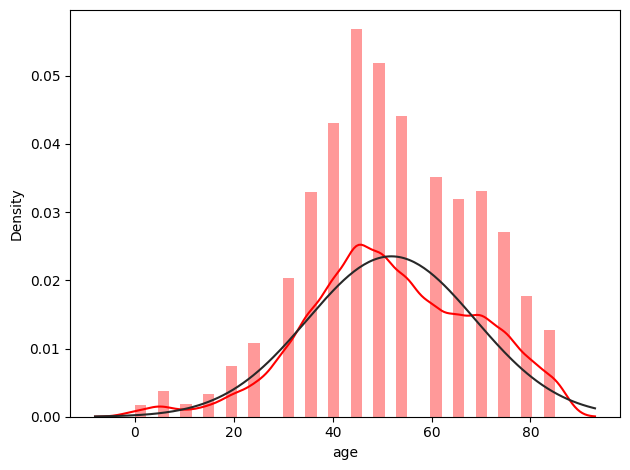

In [12]:
ax4 = fig.add_subplot(224)
sample_age = skin_df[pd.notnull(skin_df['age'])]
sns.distplot(sample_age['age'], fit=stats.norm, color='red');
ax4.set_title('Age')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.utils import resample
print(skin_df['label'].value_counts())

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [14]:
df_0 = skin_df[skin_df['label'] == 0]
df_1 = skin_df[skin_df['label'] == 1]
df_2 = skin_df[skin_df['label'] == 2]
df_3 = skin_df[skin_df['label'] == 3]
df_4 = skin_df[skin_df['label'] == 4]
df_5 = skin_df[skin_df['label'] == 5]
df_6 = skin_df[skin_df['label'] == 6]

In [15]:
n_samples=500 
df_0_balanced = resample(df_0, replace=True, n_samples=n_samples, random_state=42) 
df_1_balanced = resample(df_1, replace=True, n_samples=n_samples, random_state=42) 
df_2_balanced = resample(df_2, replace=True, n_samples=n_samples, random_state=42)
df_3_balanced = resample(df_3, replace=True, n_samples=n_samples, random_state=42)
df_4_balanced = resample(df_4, replace=True, n_samples=n_samples, random_state=42)
df_5_balanced = resample(df_5, replace=True, n_samples=n_samples, random_state=42)
df_6_balanced = resample(df_6, replace=True, n_samples=n_samples, random_state=42)

In [16]:
skin_df_balanced = pd.concat([df_0_balanced, df_1_balanced,  df_2_balanced, df_3_balanced, df_4_balanced, df_5_balanced, df_6_balanced])

In [17]:
print(skin_df_balanced['label'].value_counts())


label
0    500
1    500
2    500
3    500
4    500
5    500
6    500
Name: count, dtype: int64


In [18]:
image_path = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join('data/HAM10000/', '*', '*.jpg'))}

In [19]:
image_path

{'ISIC_0024306': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024306.jpg',
 'ISIC_0024307': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024307.jpg',
 'ISIC_0024308': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024308.jpg',
 'ISIC_0024309': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024309.jpg',
 'ISIC_0024310': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024310.jpg',
 'ISIC_0024311': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024311.jpg',
 'ISIC_0024312': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024312.jpg',
 'ISIC_0024313': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024313.jpg',
 'ISIC_0024314': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024314.jpg',
 'ISIC_0024315': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024315.jpg',
 'ISIC_0024316': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024316.jpg',
 'ISIC_0024317': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024317.jpg',
 'ISIC_0024318': 'data/HAM10000\\HAM10000_images_part_1\\ISIC_0024318.jpg',
 'ISIC_00243

In [20]:
skin_df_balanced['path'] = skin_df['image_id'].map(image_path.get)


In [21]:
SIZE = 96

In [22]:
skin_df_balanced['image'] = skin_df_balanced['path'].map(lambda x: np.asarray(Image.open(x).resize((SIZE,SIZE))))


In [23]:
n_samples = 8

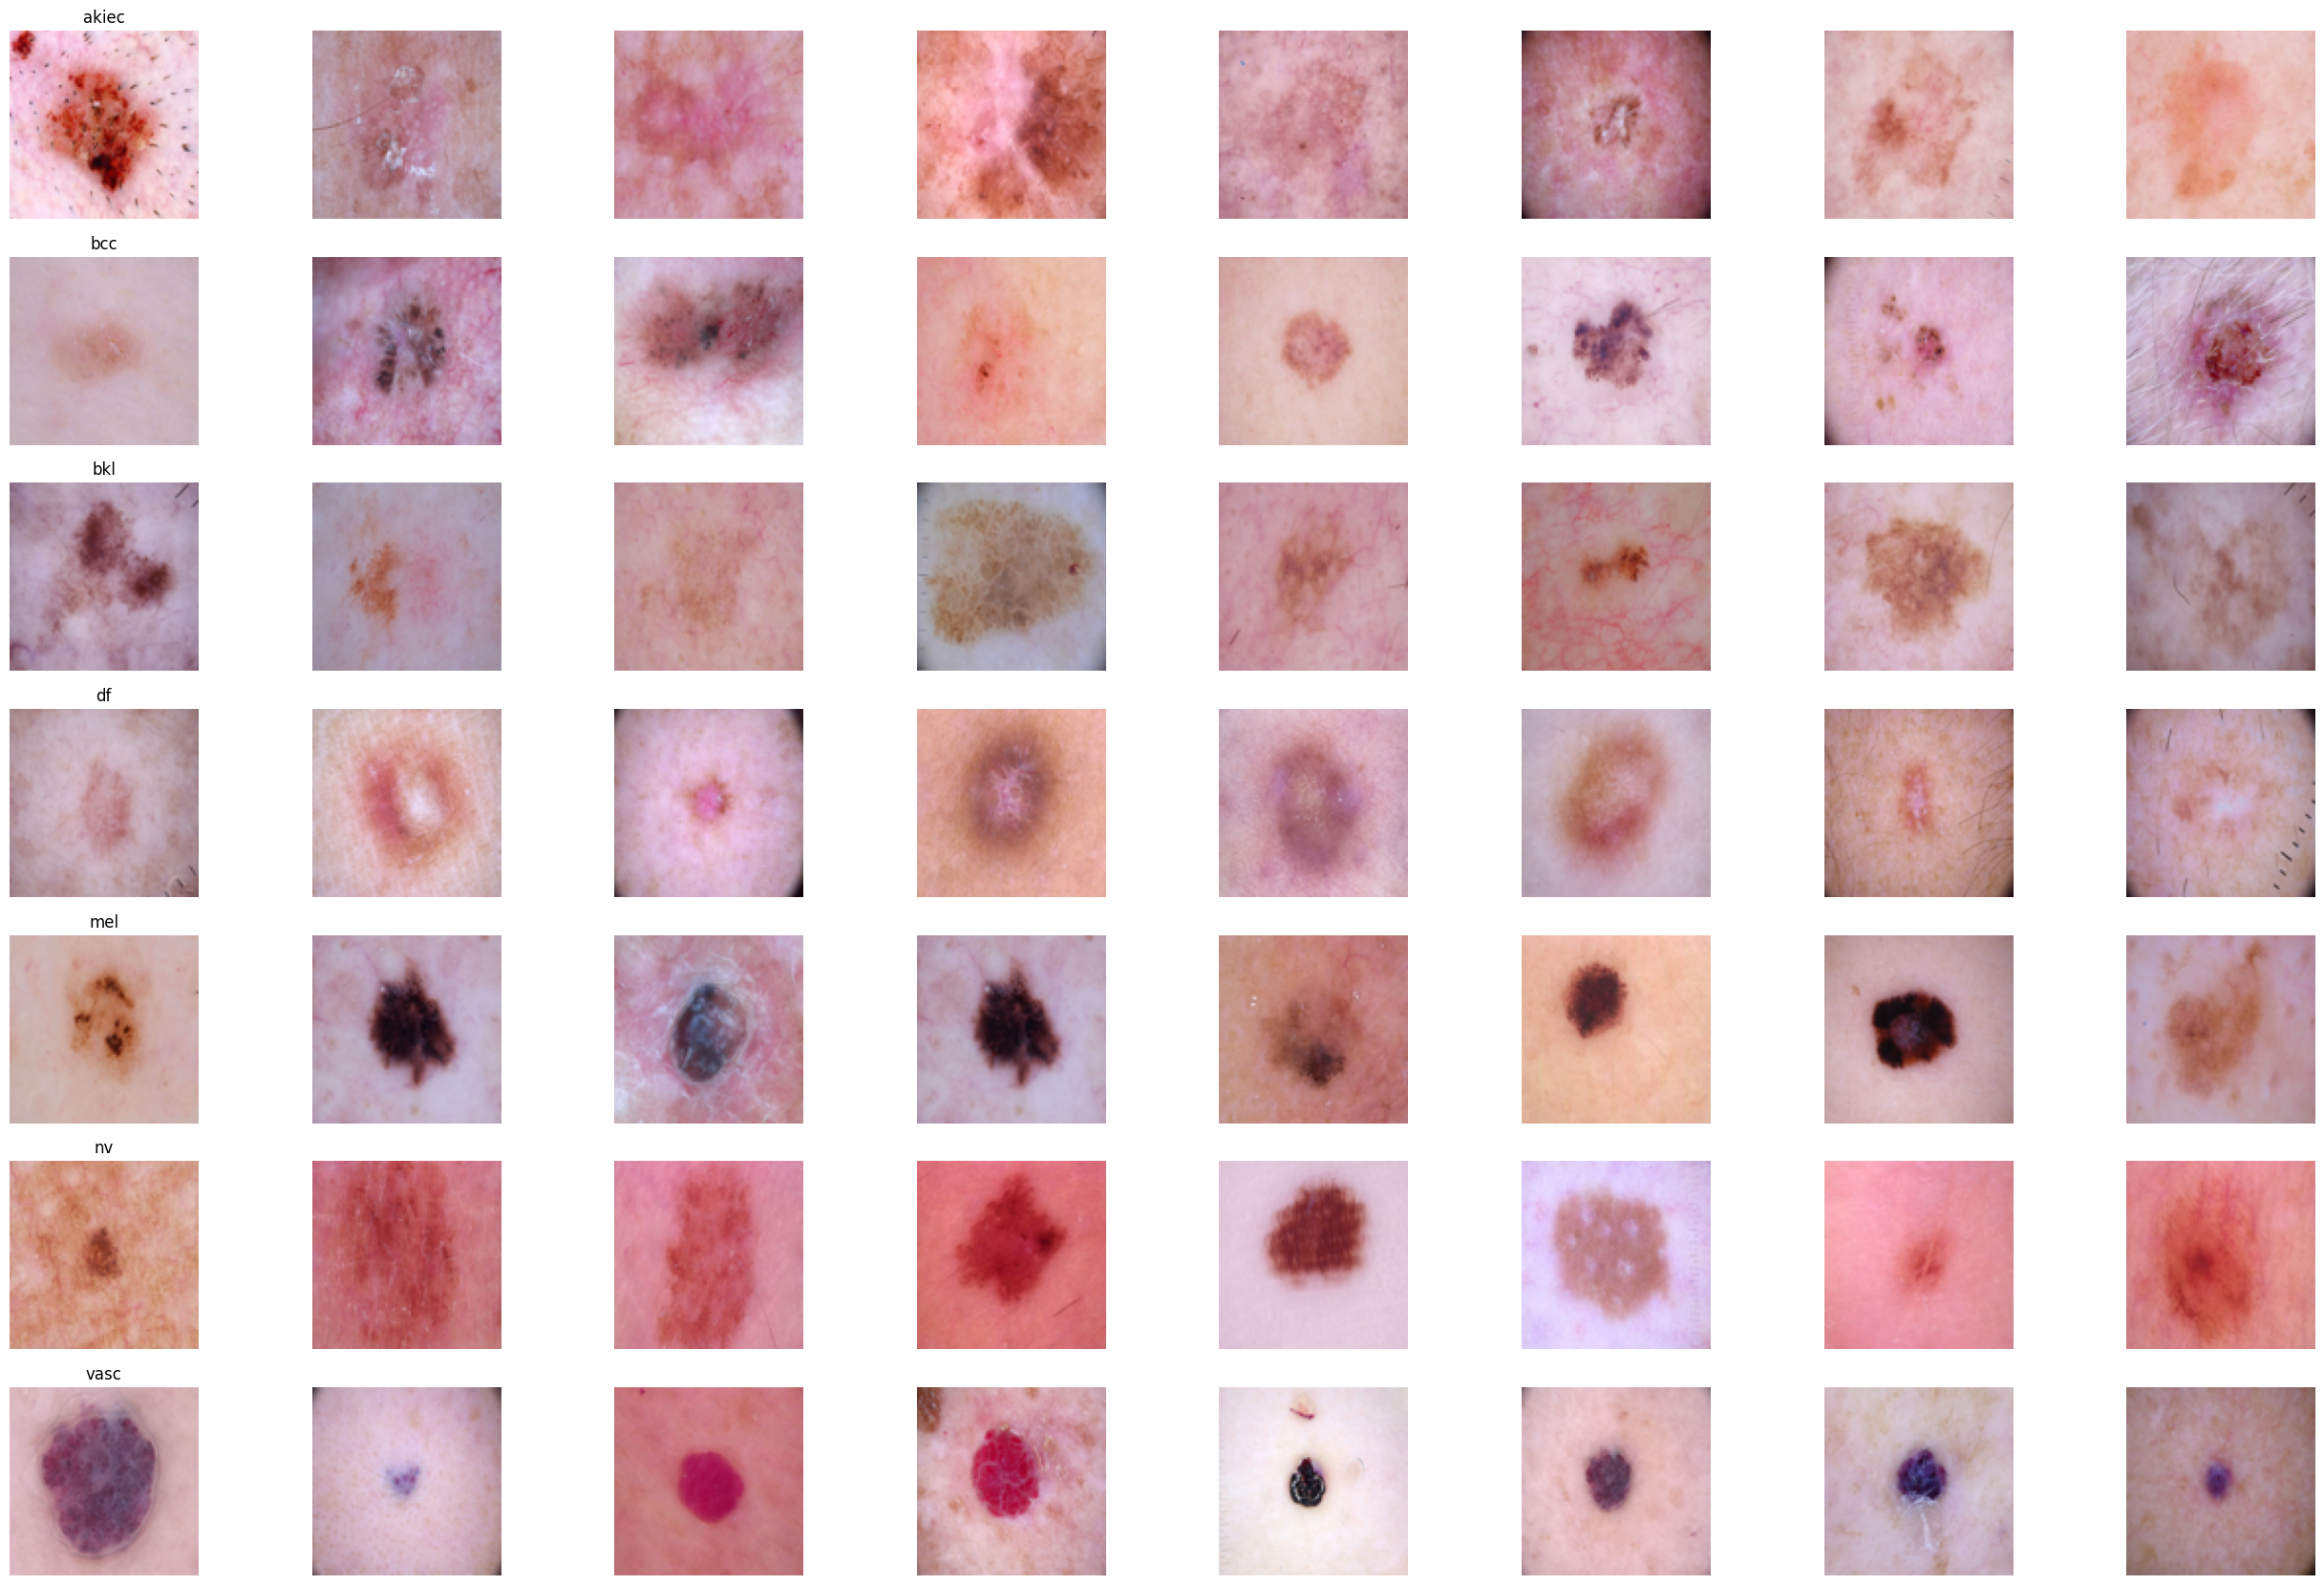

In [24]:
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, 
                                         skin_df_balanced.sort_values(['dx']).groupby('dx')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')


In [25]:
X = np.asarray(skin_df_balanced['image'].tolist())
X = X/255.  
Y=skin_df_balanced['label']  
Y_cat = to_categorical(Y, num_classes=7)

In [26]:
Y_cat

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.25, random_state=42)


In [28]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

# ✅ Load MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

# ✅ Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(96, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(patience=8, restore_best_weights=True)

# ✅ Train
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50


C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


165/165 - 13s - 80ms/step - accuracy: 0.2442 - loss: 2.1141 - val_accuracy: 0.3771 - val_loss: 1.6927
Epoch 2/50
165/165 - 10s - 58ms/step - accuracy: 0.3592 - loss: 1.6643 - val_accuracy: 0.4149 - val_loss: 1.5581
Epoch 3/50
165/165 - 9s - 56ms/step - accuracy: 0.4057 - loss: 1.5619 - val_accuracy: 0.4297 - val_loss: 1.4862
Epoch 4/50
165/165 - 9s - 55ms/step - accuracy: 0.4309 - loss: 1.4719 - val_accuracy: 0.4377 - val_loss: 1.4202
Epoch 5/50
165/165 - 9s - 53ms/step - accuracy: 0.4503 - loss: 1.4326 - val_accuracy: 0.4697 - val_loss: 1.3680
Epoch 6/50
165/165 - 9s - 55ms/step - accuracy: 0.4754 - loss: 1.3830 - val_accuracy: 0.4640 - val_loss: 1.3609
Epoch 7/50
165/165 - 9s - 53ms/step - accuracy: 0.4930 - loss: 1.3343 - val_accuracy: 0.4731 - val_loss: 1.3298
Epoch 8/50
165/165 - 9s - 54ms/step - accuracy: 0.5017 - loss: 1.3006 - val_accuracy: 0.5211 - val_loss: 1.3079
Epoch 9/50
165/165 - 9s - 54ms/step - accuracy: 0.5230 - loss: 1.2838 - val_accuracy: 0.5051 - val_loss: 1.2779
E

In [29]:
# Fine-tuning
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    verbose=2
)

Epoch 1/30
165/165 - 47s - 288ms/step - accuracy: 0.3139 - loss: 2.6889 - val_accuracy: 0.5074 - val_loss: 1.3519
Epoch 2/30
165/165 - 28s - 173ms/step - accuracy: 0.3859 - loss: 1.9936 - val_accuracy: 0.4594 - val_loss: 1.7909
Epoch 3/30
165/165 - 29s - 175ms/step - accuracy: 0.4270 - loss: 1.7895 - val_accuracy: 0.4354 - val_loss: 1.9750
Epoch 4/30
165/165 - 29s - 173ms/step - accuracy: 0.4648 - loss: 1.6173 - val_accuracy: 0.4149 - val_loss: 2.1737
Epoch 5/30
165/165 - 28s - 173ms/step - accuracy: 0.4933 - loss: 1.4548 - val_accuracy: 0.4160 - val_loss: 2.0590
Epoch 6/30
165/165 - 29s - 173ms/step - accuracy: 0.5078 - loss: 1.4076 - val_accuracy: 0.4091 - val_loss: 1.9963
Epoch 7/30
165/165 - 29s - 174ms/step - accuracy: 0.5314 - loss: 1.3025 - val_accuracy: 0.4229 - val_loss: 1.9461
Epoch 8/30
165/165 - 29s - 173ms/step - accuracy: 0.5310 - loss: 1.3050 - val_accuracy: 0.4389 - val_loss: 1.7998
Epoch 9/30
165/165 - 30s - 180ms/step - accuracy: 0.5650 - loss: 1.2067 - val_accuracy: 

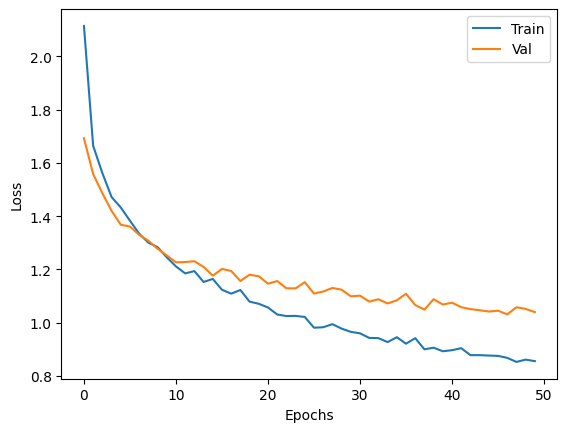

In [31]:
import matplotlib.pyplot as plt
# Plot Training vs Validation Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.show()


<Axes: >

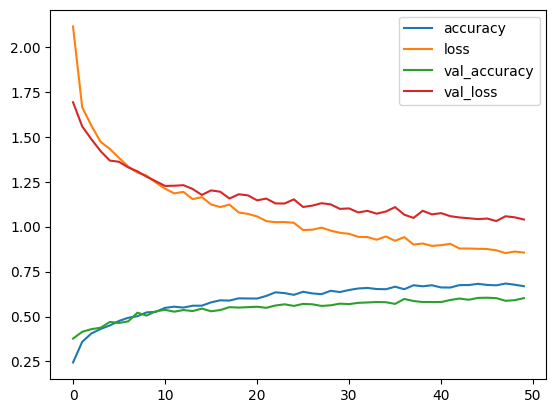

In [32]:
pd.DataFrame(history.history).plot()

## Saving Model


In [34]:
model.save('my_model.keras')

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("skin_model.h5")

# Class labels (IMPORTANT: match your LabelEncoder order)
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

IMG_SIZE = 96

def predict_image(file_path):
    img = Image.open(file_path).resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction)

    return classes[class_idx], confidence


def upload_image():
    file_path = filedialog.askopenfilename()
    if not file_path:
        return

    # Show image
    img = Image.open(file_path)
    img = img.resize((250, 250))
    img_tk = ImageTk.PhotoImage(img)

    panel.config(image=img_tk)
    panel.image = img_tk

    # Predict
    label, conf = predict_image(file_path)

    result_label.config(
        text=f"Prediction: {label}\nConfidence: {conf:.2f}",
        fg="blue"
    )


# GUI window
root = tk.Tk()
root.title("Skin Cancer Detection")
root.geometry("400x500")

# Upload button
btn = tk.Button(root, text="Upload Image", command=upload_image)
btn.pack(pady=20)

# Image panel
panel = tk.Label(root)
panel.pack()

# Result text
result_label = tk.Label(root, text="", font=("Arial", 14))
result_label.pack(pady=20)

# Run app
root.mainloop()